In [2]:
import matplotlib.pyplot as plt
import pynpoint.core.dataio
from pynpoint import *
from scripts.mcmc import residuals_rdi
import numpy as np
import emcee
import os
from pynpoint.util.image import (
    create_mask,
    polar_to_cartesian,
)
from astropy.io import fits


In [3]:
fwhm = 4.*0.01225  # (arcsec)
cent_size = fwhm  # (arcsec)
edge_size = 3.  # (arcsec)
extra_rot = 0.0  # (deg)
aperture = 5.*0.01225  # (arcsec)
pca_number = 14  # rdi H
psf_scaling = 7.94187*76.42

band = "H"
output_place = f'./output/{band}/'

working_place_in = f'./input/{band}/'

backend = emcee.backends.HDFBackend(
    os.path.join(working_place_in, "PynPoint_database.hdf5"),
    name=f'mcmc_pca_{pca_number:03.0f}_backend',
    read_only=False,
)

ndim = 3    # sep, ang (pa), mag

samples = backend.get_chain()


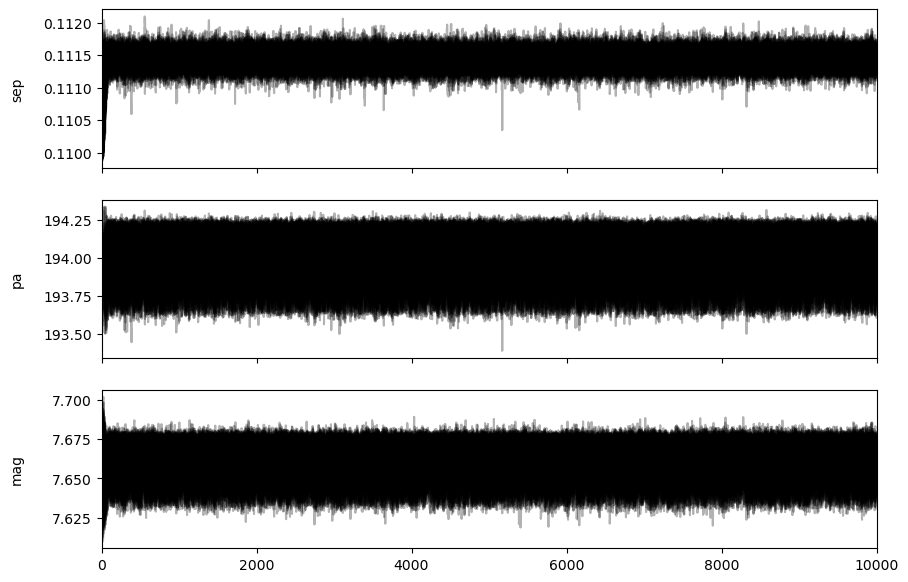

In [4]:
# plot initial chain
fig, axes = plt.subplots(ndim, figsize=(10,7), sharex=True)
labels = ['sep', 'pa', 'mag']

for i in range(ndim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(0, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)



In [5]:
burnin = int(0.2 * samples.shape[0])
samples = samples[burnin:, :, :].reshape((-1, ndim))

In [6]:
sep_percen = np.percentile(samples[:, 0], [16.0, 50.0, 84.0])
ang_percen = np.percentile(samples[:, 1], [16.0, 50.0, 84.0])
mag_percen = np.percentile(samples[:, 2], [16.0, 50.0, 84.0])

print("Median and uncertainties (20% removed as burnin):")

print(
    f"Separation (mas) = {1e3*sep_percen[1]:.2f} "
    f"(-{1e3*sep_percen[1]-1e3*sep_percen[0]:.2f} "
    f"+{1e3*sep_percen[2]-1e3*sep_percen[1]:.2f})"
)

print(
    f"Position angle (deg) = {ang_percen[1]:.2f} "
    f"(-{ang_percen[1]-ang_percen[0]:.2f} "
    f"+{ang_percen[2]-ang_percen[1]:.2f})"
)

print(
    f"Contrast (mag) = {mag_percen[1]:.2f} "
    f"(-{mag_percen[1]-mag_percen[0]:.2f} "
    f"+{mag_percen[2]-mag_percen[1]:.2f})"
)


mag_mean_err = 0.5 * (np.abs(mag_percen[1]-mag_percen[0]) + np.abs(mag_percen[2]-mag_percen[1]))
mag_max_err = np.max([np.abs(mag_percen[1]-mag_percen[0]), np.abs(mag_percen[2]-mag_percen[1])])

pa_max_err = np.max([np.abs(ang_percen[1]-ang_percen[0]), np.abs(ang_percen[2]-ang_percen[1])])
sep_max_err =  1e3*np.max([np.abs(sep_percen[1]-sep_percen[0]), np.abs(sep_percen[2]-sep_percen[1])])

print(mag_mean_err, mag_max_err)

mag_contrast = mag_percen[1]
sep = 1e3 * sep_percen[1]
pa = ang_percen[1]

print(pa_max_err, sep_max_err)
print(pa, sep)


Median and uncertainties (20% removed as burnin):
Separation (mas) = 111.45 (-0.08 +0.09)
Position angle (deg) = 193.99 (-0.06 +0.09)
Contrast (mag) = 7.66 (-0.01 +0.01)
0.006192020556456068 0.0067735859022235445
0.08552478796107721 0.09148062456922068
193.99283852966687 111.44676720373967


In [7]:
from uncertainties import ufloat, umath

def offset_to_seppa(dx, dy):
    pixscale = 0.01225
    TN_err = ufloat(0,0.04)
    sep_ufloat = umath.sqrt(dx**2 + dy**2) * pixscale
    pa_ufloat = umath.atan2(dx, -dy) + np.pi
    pa_ufloat = pa_ufloat * 180. / np.pi    # convert to degrees
    return sep_ufloat, pa_ufloat

def offset_to_seppa_witherror(dx, dy):
    pixscale = ufloat(0.01225, 0.00021)
    TN_err = ufloat(0,0.04)
    centering_error = 2.5e-3 / pixscale.n                               # centering error of 2.5 mas in pixels
    centering_error_uf = ufloat(0, centering_error)
    dx = dx + centering_error_uf
    dy = dy + centering_error_uf
    sep_ufloat = umath.sqrt(dx**2 + dy**2) * pixscale
    pa_ufloat = umath.atan2(dx, -dy) + np.pi + (TN_err / 180. * np.pi)
    pa_ufloat = pa_ufloat * 180. / np.pi    # convert to degrees
    return sep_ufloat, pa_ufloat

def seppa_to_offset(sep, pa):
    pixscale = 0.01225
    pa_rad = pa * np.pi / 180.
    theta = pa_rad - np.pi
    r = sep / pixscale
    dx = r * umath.sin(theta)
    dy = -r * umath.cos(theta)
    return dx, dy

sepuf = ufloat(sep_percen[1], 1e-3*sep_max_err)
pauf = ufloat(ang_percen[1], pa_max_err)
print("original sep and pa")
print(sepuf)
print(pauf)

xoff, yoff = seppa_to_offset(sepuf, pauf)
print("converted offset")
print(xoff)
print(yoff)

## correction from centering
#xoff_c = xoff - 0.5
#yoff_c = yoff - 0.5

# with error
print("converted back to sep and pa")
sepuf_n, pauf_n = offset_to_seppa_witherror(xoff, yoff)

print("reconverted pa and sep")
print(sepuf_n)
print(pauf_n)


## with error, corrected
#print("corrected and converted back to sep and pa")
#sepuf_n, pauf_n = offset_to_seppa_witherror(xoff_c, yoff_c)
#
#print("reconverted pa and sep")
#print(sepuf_n)
#print(pauf_n)

print("sep:", sepuf_n.n * 1e3, "+/-", sepuf_n.s*1e3)
print("pa:", pauf_n.n, "+/-", pauf_n.s)



original sep and pa
0.11145+/-0.00009
193.99+/-0.09
converted offset
2.200+/-0.013
-8.828+/-0.008
converted back to sep and pa
reconverted pa and sep
0.1114+/-0.0026
194.0+/-1.6
sep: 111.44676720373968 +/- 2.641140370986713
pa: 193.99283852966687 +/- 1.5607711859378746


In [8]:
# results mcmc
#sep = 0.10568
#ang = 195.67
#mag = 7.39
#print(sep, ang, mag)

# doesn't work
# plot residuals
#pipeline = Pypeline(working_place_in, './', output_place)
#
#images = pipeline.get_data(f'science_crop_tc_masked')
#ref_data = pipeline.get_data(f'ref_crop_tc_masked')
#psf = pipeline.get_data(f'flux_crop_mean')
#parang = np.array(pipeline.list_attributes('science')['PARANG'])
#pixscale = pipeline.list_attributes('science')['PIXSCALE']
#
#im_shape = images.shape[-2:]
#print("imshape", im_shape)
#mask = create_mask(im_shape[-2:], (cent_size, edge_size))
#print(parang, pixscale)
#pipeline.run()


In [9]:
#residual_im = residuals_rdi(np.array([sep_percen[1], ang_percen[1], mag_percen[1]]), images, ref_data,
#                            psf, mask, parang, psf_scaling, pixscale, pca_number,
#                            0.0, "mean")
#
#
#fits.writeto(f"output/{band}/mcmc_residuals_test.fits", residual_im, overwrite=True)

In [10]:
pipeline = Pypeline(working_place_in, './', output_place)
pipeline.list_attributes('offset')
offset = pipeline.get_data('offset')

print(pipeline.get_tags())

PynPoint v0.11.0

A new version (0.11.2) is available!

Want to stay informed about updates, bug fixes, and new features?
Please consider using the 'Watch' button on the Github page:
https://github.com/PynPoint/PynPoint

Working place: ./input/H/
Input place: ./
Output place: ./output/H/

Database: ./input/H/PynPoint_database.hdf5
Configuration: ./input/H/PynPoint_config.ini

Number of CPUs: 64
Number of threads: not set

----------------------------
Attribute overview of offset
----------------------------

Static attributes:

   - History: RemoveLinesModule = number of lines = (0, 0, 0, 0)

   - History: SystematicErrorModule = sep = 0.110, pa = 194.0, mag = 7.7

   - PIXSCALE = 0.01225

   - edge_size = 0.2

Non-static attributes:

   - FILES = [b'./input/H/sci.fits']

   - INDEX = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47]

   - NFRAMES = [48]


In [11]:
print(offset.shape)
degrees = np.linspace(0, 359, 360, endpoint=True)
labels = ['dsep', 'dpa', 'dmag', 'dx', 'dy']
labels2 = ['sep', 'pa', 'mag', 'x', 'y']
print(offset[0,:])

(360, 5)
[ 0.00341967  0.76407452  0.28217845 -0.11602223  0.27993005]


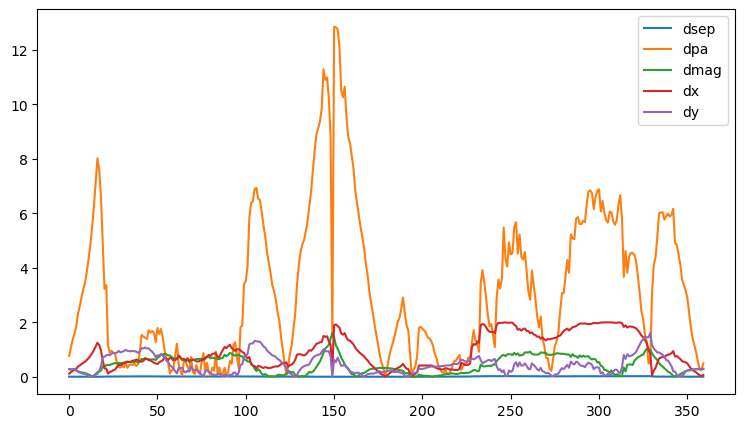

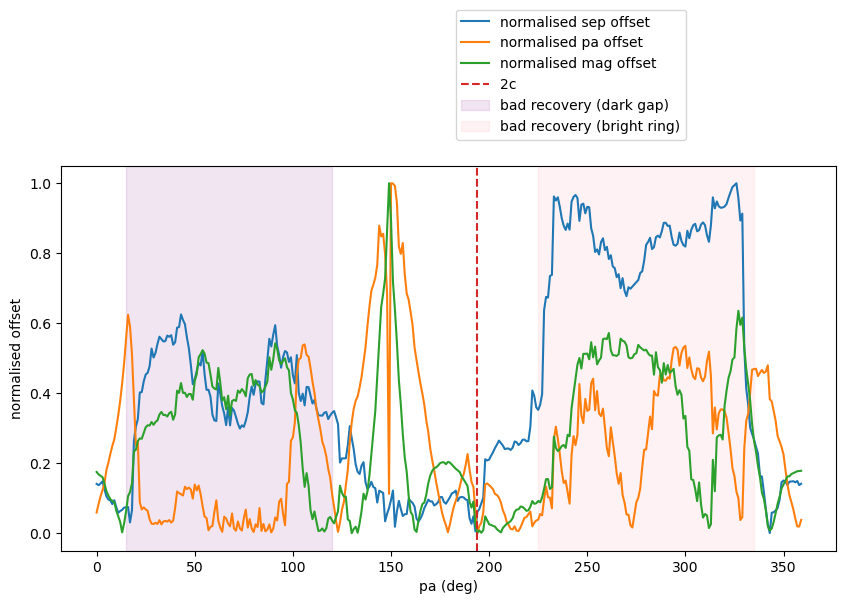

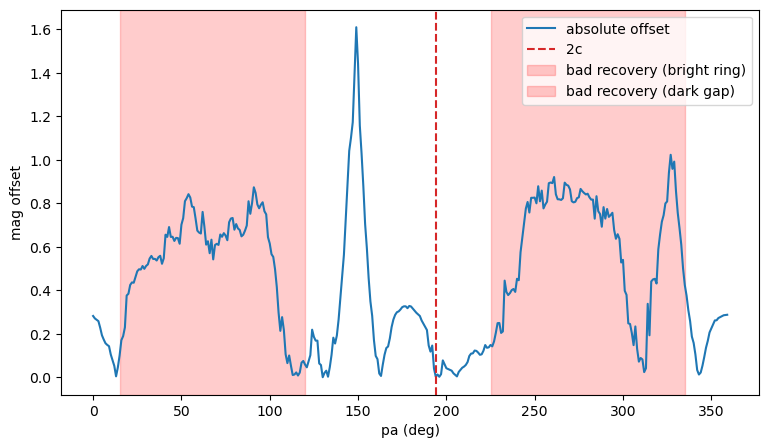

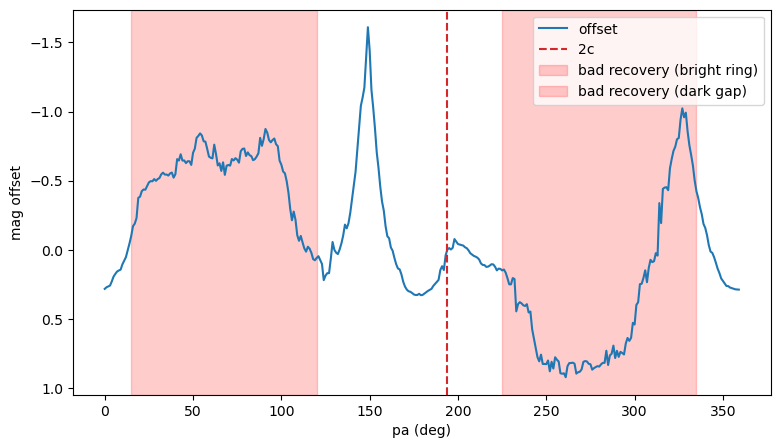

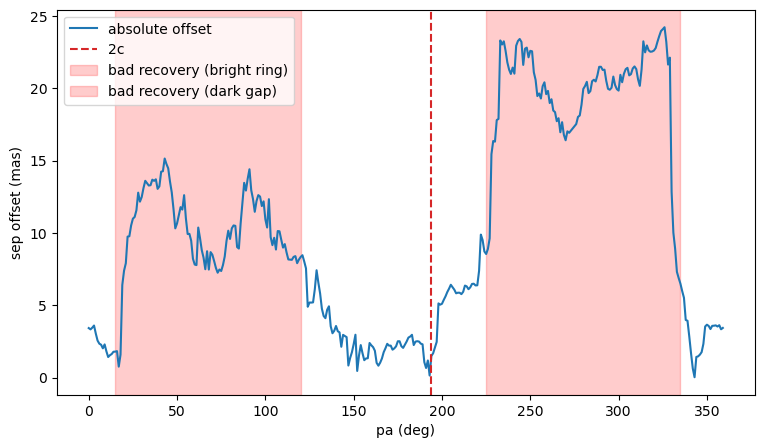

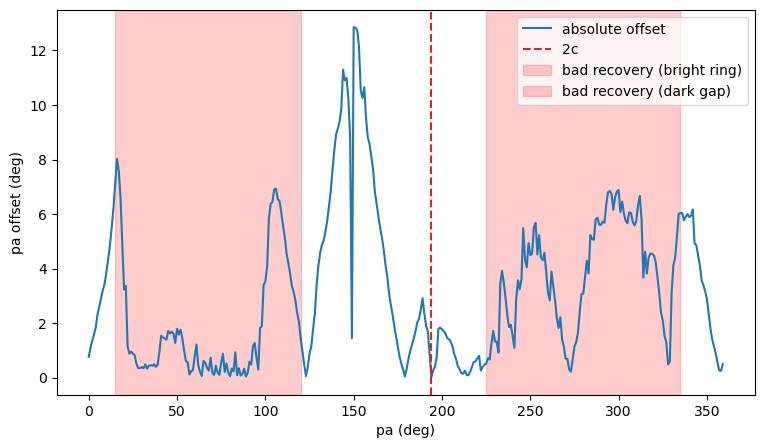

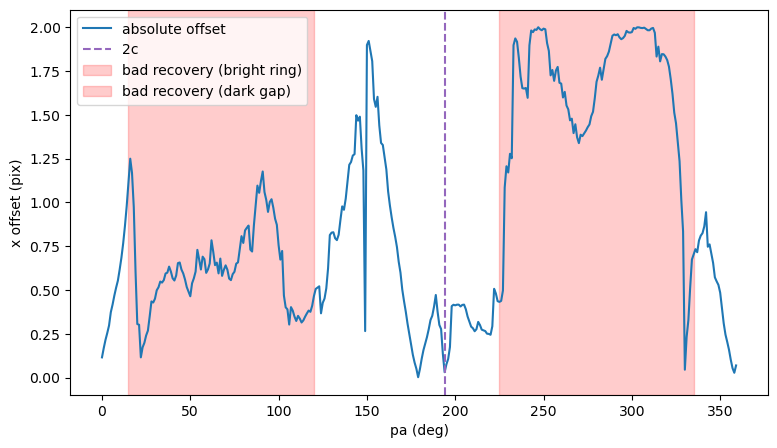

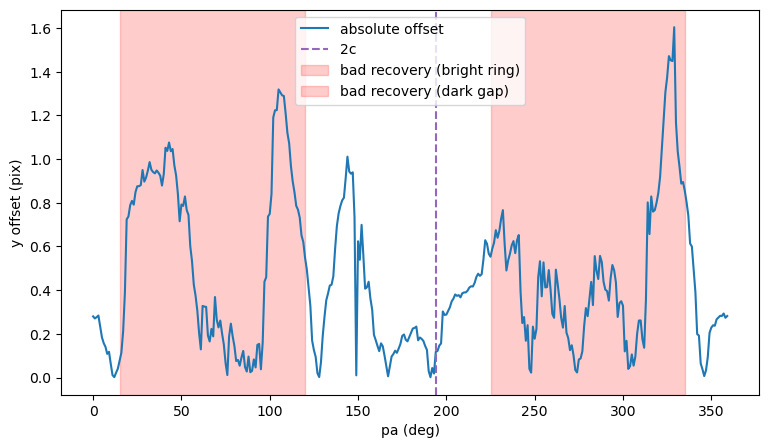

In [12]:
# plot errors as a function of angle
fig, ax = plt.subplots(1, figsize=(9,5))
for i in range(len(labels)):
    ax.plot(degrees, np.abs(offset[:,i]), label=labels[i])
plt.legend()
plt.show()
ang = pauf_n.n

fig, ax = plt.subplots(1, figsize=(10,5))
for i in range(3):
    ax.plot(degrees, np.abs(offset[:,i])/np.max(np.abs(offset[:,i])), label="normalised "+labels2[i]+" offset")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=15, xmax=120, color="purple", alpha=0.1, label="bad recovery (dark gap)")
ax.axvspan(xmin=225, xmax=335, color="pink", alpha=0.2, label="bad recovery (bright ring)")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("normalised offset")
plt.legend(bbox_to_anchor=(0.5, 1.05))
plt.show()

# just mag
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,2]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("mag offset")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")

ax.legend()
plt.show()

# just mag
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, offset[:,2], label="offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("mag offset")
ax.invert_yaxis()
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")

ax.legend()
plt.show()

# just sep
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,0])*1000, label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("sep offset (mas)")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()

# just pa
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,1]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("pa offset (deg)")
ax.axvline(x=ang, ls="--", c="C3", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()

# just x
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,3]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("x offset (pix)")
ax.axvline(x=ang, ls="--", c="C4", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()

# just y
fig, ax = plt.subplots(1, figsize=(9,5))
ax.plot(degrees, np.abs(offset[:,4]), label="absolute offset")
ax.set_xlabel("pa (deg)")
ax.set_ylabel("y offset (pix)")
ax.axvline(x=ang, ls="--", c="C4", label="2c")
ax.axvspan(xmin=225, xmax=335, color="red", alpha=0.2, label="bad recovery (bright ring)")
ax.axvspan(xmin=15, xmax=120, color="red", alpha=0.2, label="bad recovery (dark gap)")
ax.legend()
plt.show()



In [13]:
sep_percen = np.percentile(offset[:, 0], [16.0, 50.0, 84.0])
ang_percen = np.percentile(offset[:, 1], [16.0, 50.0, 84.0])
mag_percen = np.percentile(offset[:, 2], [16.0, 50.0, 84.0])
x_pos_percen = np.percentile(offset[:, 3], [16.0, 50.0, 84.0])
y_pos_percen = np.percentile(offset[:, 4], [16.0, 50.0, 84.0])

print("\nMedian offset and uncertainties:")

print(
    f"   - Position x (pixels) = {x_pos_percen[1]:.2f} "
    f"(-{x_pos_percen[1]-x_pos_percen[0]:.2f} "
    f"+{x_pos_percen[2]-x_pos_percen[1]:.2f})"
)

print(
    f"   - Position y (pixels) = {y_pos_percen[1]:.2f} "
    f"(-{y_pos_percen[1]-y_pos_percen[0]:.2f} "
    f"+{y_pos_percen[2]-y_pos_percen[1]:.2f})"
)

print(
    f"   - Separation (mas) = {1e3*sep_percen[1]:.2f} "
    f"(-{1e3*sep_percen[1]-1e3*sep_percen[0]:.2f} "
    f"+{1e3*sep_percen[2]-1e3*sep_percen[1]:.2f})"
)

print(
    f"   - Position angle (deg) = {ang_percen[1]:.2f} "
    f"(-{ang_percen[1]-ang_percen[0]:.2f} "
    f"+{ang_percen[2]-ang_percen[1]:.2f})"
)

print(
    f"   - Contrast (mag) = {mag_percen[1]:.2f}"
    f"(-{mag_percen[1]-mag_percen[0]:.2f} "
    f"+{mag_percen[2]-mag_percen[1]:.2f})"
)


Median offset and uncertainties:
   - Position x (pixels) = -0.17 (-1.60 +0.87)
   - Position y (pixels) = -0.05 (-0.73 +0.51)
   - Separation (mas) = -8.90 (-11.56 +10.62)
   - Position angle (deg) = 0.17 (-4.30 +4.37)
   - Contrast (mag) = 0.02(-0.68 +0.52)


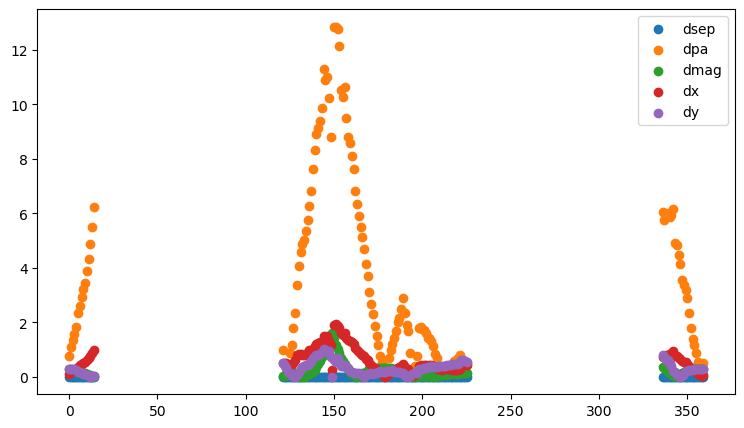


Median offset_cut and uncertainties:
   - Position x (pixels) = -0.11 (-0.51 +0.90)
   - Position y (pixels) = 0.11 (-0.40 +0.28)
   - Separation (mas) = 0.92 (-6.90 +1.59)
   - Position angle (deg) = -0.15 (-5.02 +4.05)
   - Contrast (mag) = 0.08(-0.28 +0.19)


In [30]:
#t1 = np.logical_and(offset>=0, offset<=15)
degrees_mask = np.logical_or.reduce((np.logical_and(degrees>=0, degrees<15), np.logical_and(degrees>120, degrees<=225), np.logical_and(degrees>335, degrees<=360)))
offset_cut = offset[degrees_mask]
degrees_cut = degrees[degrees_mask]
#print(offset_cut)


# plot errors as a function of angle
fig, ax = plt.subplots(1, figsize=(9,5))
for i in range(len(labels)):
    ax.scatter(degrees_cut, np.abs(offset_cut[:,i]), label=labels[i])
plt.legend()
plt.show()

sep_percen = np.percentile(offset_cut[:, 0], [16.0, 50.0, 84.0])
ang_percen = np.percentile(offset_cut[:, 1], [16.0, 50.0, 84.0])
mag_percen = np.percentile(offset_cut[:, 2], [16.0, 50.0, 84.0])
x_pos_percen = np.percentile(offset_cut[:, 3], [16.0, 50.0, 84.0])
y_pos_percen = np.percentile(offset_cut[:, 4], [16.0, 50.0, 84.0])

print("\nMedian offset_cut and uncertainties:")

print(
    f"   - Position x (pixels) = {x_pos_percen[1]:.2f} "
    f"(-{x_pos_percen[1]-x_pos_percen[0]:.2f} "
    f"+{x_pos_percen[2]-x_pos_percen[1]:.2f})"
)

print(
    f"   - Position y (pixels) = {y_pos_percen[1]:.2f} "
    f"(-{y_pos_percen[1]-y_pos_percen[0]:.2f} "
    f"+{y_pos_percen[2]-y_pos_percen[1]:.2f})"
)

print(
    f"   - Separation (mas) = {1e3*sep_percen[1]:.2f} "
    f"(-{1e3*sep_percen[1]-1e3*sep_percen[0]:.2f} "
    f"+{1e3*sep_percen[2]-1e3*sep_percen[1]:.2f})"
)

print(
    f"   - Position angle (deg) = {ang_percen[1]:.2f} "
    f"(-{ang_percen[1]-ang_percen[0]:.2f} "
    f"+{ang_percen[2]-ang_percen[1]:.2f})"
)

print(
    f"   - Contrast (mag) = {mag_percen[1]:.2f}"
    f"(-{mag_percen[1]-mag_percen[0]:.2f} "
    f"+{mag_percen[2]-mag_percen[1]:.2f})"
)


In [31]:
# total mag uncertainty

mag_sys_mean_err = 0.5 * (np.abs(mag_percen[1]-mag_percen[0]) + np.abs(mag_percen[2]-mag_percen[1]))
mag_sys_max_err = np.max([np.abs(mag_percen[1]-mag_percen[0]), np.abs(mag_percen[2]-mag_percen[1])])
print("sys", mag_sys_mean_err, mag_sys_max_err)

err_mean_comb = np.sqrt(mag_mean_err**2 + mag_sys_mean_err**2)
err_max_comb = np.sqrt(mag_max_err**2 + mag_sys_max_err**2)

print("\nnpca", pca_number)
print("mag contrast", mag_contrast)
print("tot mean err", err_mean_comb)
print("tot max err", err_max_comb)

pa_sys_max_err = np.max([np.abs(ang_percen[1]-ang_percen[0]), np.abs(ang_percen[2]-ang_percen[1])])
print("sys pa max", pa_sys_max_err)

err_max_comb_pa = np.sqrt(pa_max_err**2 + pa_sys_max_err**2)
print("pa", pa)
print("pa err comb", err_max_comb_pa)

sep_sys_max_err = 1e3 * np.max([np.abs(sep_percen[1]-sep_percen[0]), np.abs(sep_percen[2]-sep_percen[1])])
print("sys", sep_sys_max_err)

err_max_comb_sep = np.sqrt(sep_max_err**2 + sep_sys_max_err**2)
print("sep", sep)
print("sep err comb", err_max_comb_sep)

magnitude_contrast = ufloat(mag_contrast, err_max_comb)
print("contrast", magnitude_contrast)

star_H = ufloat(8.591, 0.078)
print("star H", star_H)
parallax = ufloat(7.464925176349439, 0.021432146)
distance = 1000/parallax

planet_app_mag = magnitude_contrast + star_H
print("app mag", planet_app_mag)

planet_abs_mag = 5 - 5*umath.log10(distance) + planet_app_mag

print("abs mag", planet_abs_mag)


sys 0.23323761492779818 0.2774298161167237

npca 14
mag contrast 7.660606076296333
tot mean err 0.23331979370764805
tot max err 0.2775124940187989
sys pa max 5.017834580283527
pa 193.99283852966687
pa err comb 5.0185633765496025
sys 6.903511703635868
sep 111.44676720373967
sep err comb 6.904117796424752
contrast 7.66+/-0.28
star H 8.59+/-0.08
app mag 16.25+/-0.29
abs mag 10.62+/-0.29


In [32]:
print("systematic pa and sep errors")
print(pa_sys_max_err)
print(1e-3*sep_sys_max_err)
print("original pa and sep")
print(pauf_n)
print(sepuf_n)

#combine
pauf_n_comb = pauf_n + ufloat(0, pa_sys_max_err)
sepuf_n_comb = sepuf_n + ufloat(0, 1e-3*sep_sys_max_err)
print("combined pa and sep")
print(pauf_n_comb)
print(sepuf_n_comb)

systematic pa and sep errors
5.017834580283527
0.006903511703635868
original pa and sep
194.0+/-1.6
0.1114+/-0.0026
combined pa and sep
194+/-5
0.111+/-0.007


In [34]:
print("sep:", sepuf_n_comb.n * 1e3, "+/-", sepuf_n_comb.s*1e3)
print("pa:", pauf_n_comb.n, "+/-", pauf_n_comb.s)
print("planet contrast:", magnitude_contrast.n,"+/-", magnitude_contrast.s)
print("planet apparent magnitude:", planet_app_mag.n,"+/-", planet_app_mag.s)
print("planet absolute mag:", planet_abs_mag.n, "+/-", planet_abs_mag.s)


sep: 111.44676720373968 +/- 7.391488097906485
pa: 193.99283852966687 +/- 5.25496627676554
planet contrast: 7.660606076296333 +/- 0.2775124940187989
planet apparent magnitude: 16.251606076296333 +/- 0.28826582235244935
planet absolute mag: 10.616733371255666 +/- 0.288333230921267
